### 복습

<Axes: xlabel='sex', ylabel='total_bill'>

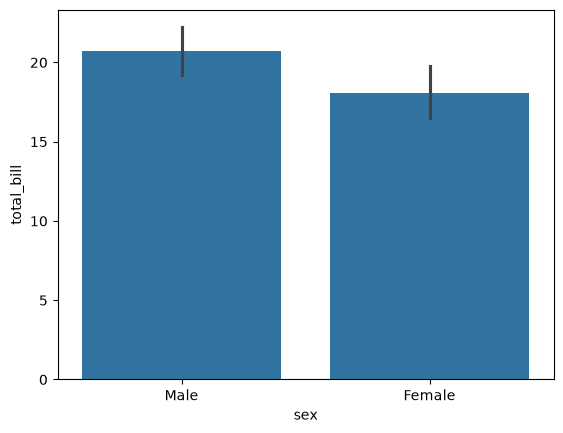

In [2]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

tips = sns.load_dataset('tips')

sns.barplot(data=tips, x='sex', y='total_bill')

Text(0.5, 1.0, 'Barplot of Count by Sex')

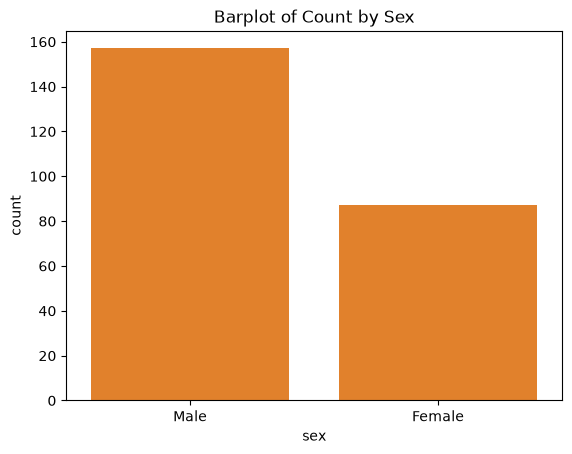

In [5]:
sns.countplot(data=tips, x='sex')
cntplot = sns.countplot(data=tips, x='sex')
cntplot.set_title('Barplot of Count by Sex')

Text(0.5, 1.0, 'Boxplot of Tips by Gender')

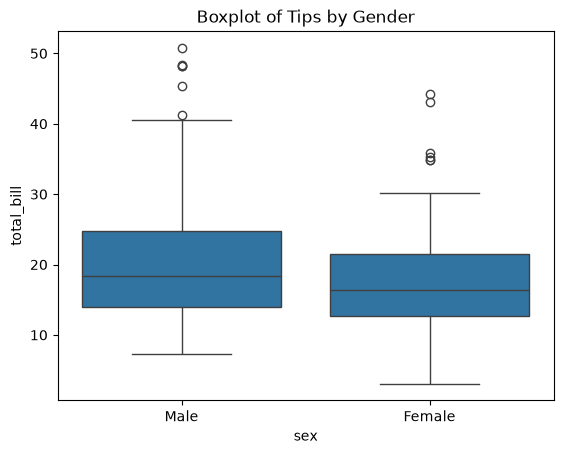

In [7]:
bp = sns.boxplot(x='sex', y='total_bill', data=tips)
bp.set_title('Boxplot of Tips by Gender')

Text(0.5, 1.0, 'Total Bill Histogram')

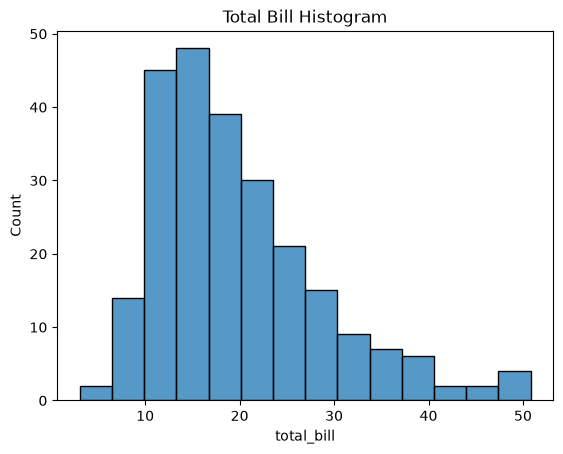

In [9]:
sns.histplot(tips['total_bill']).set_title('Total Bill Histogram')

# 머신러닝 회귀

In [27]:
import pandas as pd
titanic = pd.read_csv('../da_data/titanic.csv')
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# int만 있어야 할 컬럼에 Nan이 있으면 float이 됨.

## 단변량 분석

In [16]:
# Age, Cabin, Embarked에 결측값이 있는 상태

titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### 통계량 또는 그래프를 통한 EDA
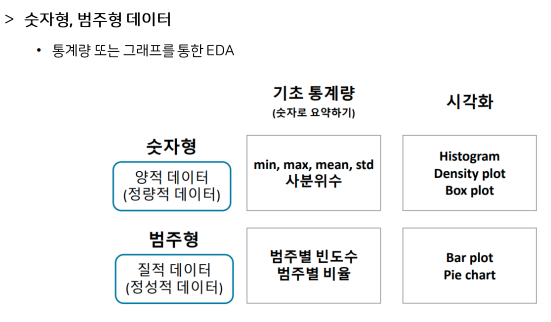

In [ ]:
# 현재 Age의 결측값이 처리되지 않은 상태

titanic['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

## 나이를 그린 다양한 그래프

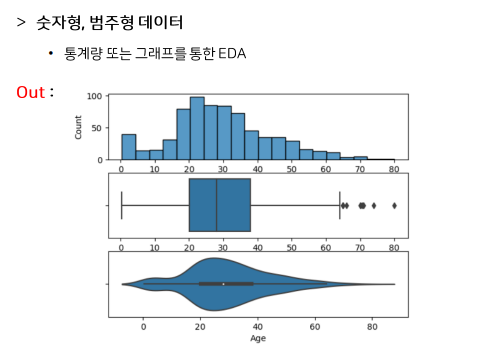

<Axes: xlabel='Age'>

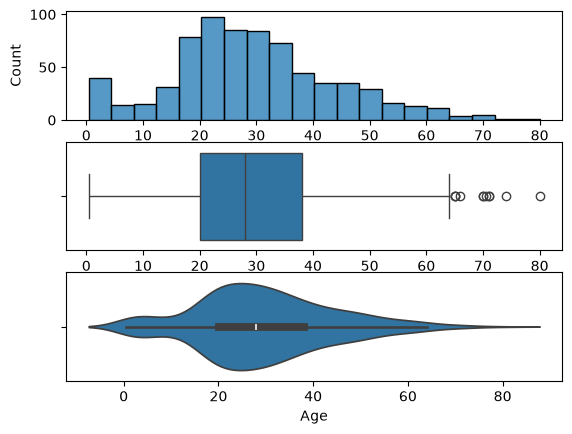

In [ ]:
# 파이썬 데이터 시각화 라이브러리 matplotlib
# matplotlib 기반으로 만든 시각화 라이브러리
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplot(3, 1, 1)
sns.histplot(data = titanic, x='Age')
plt.subplot(3, 1, 2)
sns.boxplot(data = titanic, x='Age')
plt.subplot(3, 1, 3)
sns.violinplot(data = titanic, x='Age')

In [ ]:
# Fare의 범위가 $0부터 $512 
# -> 요금을 내지 않은 사람이 있고, 최고급 객실에 서비스 풀추가시 $512일 것으로 추정
# 평균 요금은 $32.2이지만 75%가 $31 이내인 것을 보아 
# Fare 데이터는 왼쪽으로 굉장히 치우쳤음을 알 수 있다.

# 가능성
# 1. 선원 또는 근무자 -> 정답 (나중에 등장)
# 2. 아기
# 3. 공짜 티켓

titanic['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

[1 1]
[7.9104 0.    ]


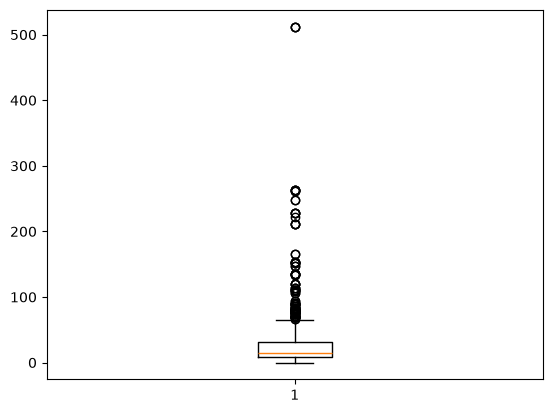

In [34]:
box = plt.boxplot(titanic['Fare'])

print(box['whiskers'][0].get_xdata())
print(box['whiskers'][0].get_ydata())

<Axes: xlabel='Fare'>

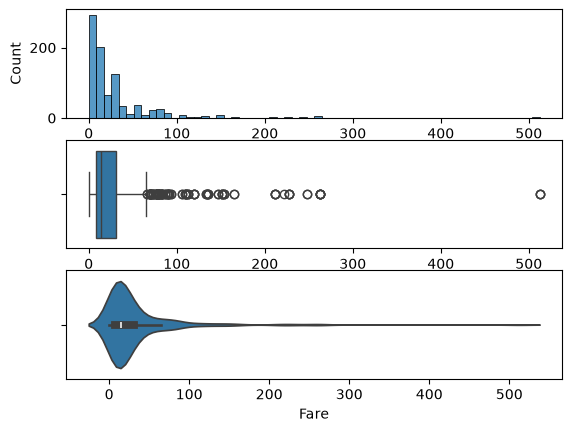

In [24]:
plt.subplot(3, 1, 1)
sns.histplot(data=titanic, x='Fare')
plt.subplot(3, 1, 2)
sns.boxplot(data=titanic, x='Fare')
plt.subplot(3, 1, 3)
sns.violinplot(data=titanic, x='Fare')

In [35]:
# 이상치 판단하는 방법
# IQR(Interquartile Range, 사분위수 범위) 방법

# 타이타닉의 Fare 컬럼의 Q3(75%)에서 Q1(25%)를 빼서 직접 IQR 지정
IQR = titanic['Fare'].quantile(0.75) - titanic['Fare'].quantile(0.25)

# 상한값 범위
high_border = titanic['Fare'].quantile(0.75) + IQR*(1.5)

# 하한값 범위
low_border = titanic['Fare'].quantile(0.25) - IQR*(1.5)

# 사분위수 출력
print(high_border, low_border)

65.6344 -26.724


<Axes: xlabel='Fare'>

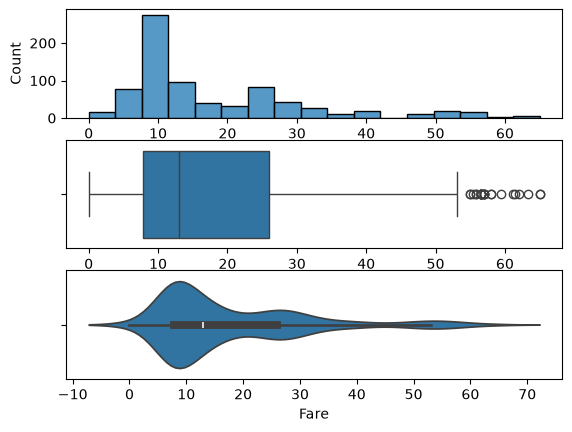

In [37]:
# 이상값를 지운 값(상한값 범위와 하한값 범위 사이)을 titanic2로 저장
# 하지만 이상값이 사라짐에 따라 중앙값이 조정되어 다시 이상값이 생김.
titanic2 = titanic[(titanic['Fare'] < high_border) & 
                   (titanic['Fare'] > low_border)]

plt.subplot(3, 1, 1)
sns.histplot(data=titanic2, x='Fare')
plt.subplot(3, 1, 2)
sns.boxplot(data=titanic2, x='Fare')
plt.subplot(3, 1, 3)
sns.violinplot(data=titanic2, x='Fare')

In [33]:
# Fare가 65.6344보다 작은 것 중에서 가장 큰 것 찾기
titanic[titanic['Fare'] < 65.6344]['Fare'].max()

np.float64(65.0)

<Axes: xlabel='Fare'>

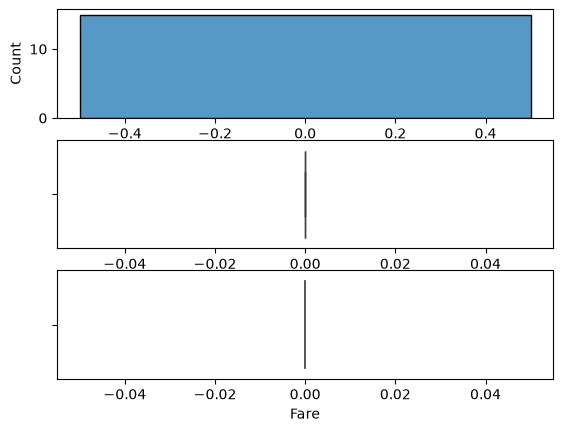

In [44]:
# 이상치 판단

# 수학 및 과학 연산을 위한 파이썬 패키지
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# z_score : 평균에서 떨어진 정도로 이상치 검출, 2~3의 값으로 검출
# z = (X-평균) / 표준편차
z_score = np.abs(titanic['Fare'] - titanic['Fare'].mean() / titanic['Fare'].std())

# 신뢰구간 95%
titanic3 = titanic[z_score < 2.5]

plt.subplot(3, 1, 1)
sns.histplot(data=titanic3, x='Fare')
plt.subplot(3, 1, 2)
sns.boxplot(data=titanic3, x='Fare')
plt.subplot(3, 1, 3)
sns.violinplot(data=titanic3, x='Fare')

In [45]:
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [59]:
# 승객 클래스를 개수와 비율로 출력해보기
# 다른 관점에서의 해석을 위해

print(titanic['Pclass'].value_counts())
print(titanic['Pclass'].value_counts() / titanic.shape[0])

Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Pclass
3    0.551066
1    0.242424
2    0.206510
Name: count, dtype: float64


In [62]:
titanic['Pclass'].unique()

array([3, 1, 2])

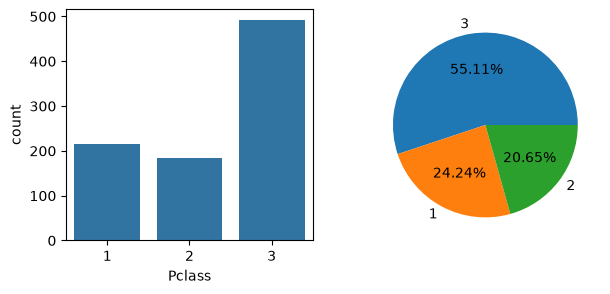

In [64]:
p_cnt = titanic['Pclass'].value_counts()
plt.figure(figsize = (7, 3))
plt.subplot(1,2,1)
sns.countplot(data = titanic, x = 'Pclass')
plt.subplot(1,2,2)
plt.pie(p_cnt.values, labels = p_cnt.index, autopct = '%.2f%%') 

In [60]:
print(titanic['Sex'].value_counts())
print(titanic['Sex'].value_counts() / titanic.shape[0])

Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      0.647587
female    0.352413
Name: count, dtype: float64


In [58]:
print(titanic['Survived'].value_counts())
print(titanic['Survived'].value_counts() / titanic.shape[0])

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: count, dtype: float64
